## Simple Classification Tree


In [ ]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
print(iris.keys())
X_temp, X_test, y_temp, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, stratify=iris.target, random_state=121)

X_train, X_val, y_train, y_val = train_test_split(
    # val % = (desired %)/(1 - test %)
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=121)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [108]:
# Grid search over max_depth, min_samples_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
param_grid = {
    'max_depth': [3, 4],
    'min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = tree.DecisionTreeClassifier(class_weight='balanced', random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'recall': 'recall_macro',
    'roc_auc': 'roc_auc_ovr'
}

grid_search = GridSearchCV(
    estimator=clf, param_grid=param_grid, cv=cv, n_jobs=-1, scoring=scoring, refit='roc_auc', verbose=3)


grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


[CV 2/5] END max_depth=3, min_samples_split=2; accuracy: (test=0.889) f1_macro: (test=0.889) recall: (test=0.889) roc_auc: (test=0.931) total time=   0.0s
[CV 1/5] END max_depth=3, min_samples_split=2; accuracy: (test=0.889) f1_macro: (test=0.886) recall: (test=0.889) roc_auc: (test=1.000) total time=   0.0s
[CV 1/5] END max_depth=4, min_samples_split=2; accuracy: (test=1.000) f1_macro: (test=1.000) recall: (test=1.000) roc_auc: (test=1.000) total time=   0.0s
[CV 4/5] END max_depth=3, min_samples_split=2; accuracy: (test=0.833) f1_macro: (test=0.832) recall: (test=0.833) roc_auc: (test=0.875) total time=   0.0s
[CV 3/5] END max_depth=3, min_samples_split=5; accuracy: (test=0.944) f1_macro: (test=0.944) recall: (test=0.944) roc_auc: (test=0.958) total time=   0.0s
[CV 5/5] END max_depth=3, min_samples_split=2; accuracy: (test=0.889) f1_macro: (test=0.886) recall: (test=0.889) roc_auc: (test=0.958) total time=   0.0s
[CV 3/5] END max_depth=3, min_samples_split=2; accuracy: (test=0.944) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4], 'min_samples_split': [2, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'recall': 'recall_macro', 'roc_auc': 'roc_auc_ovr'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messa

In [105]:
import numpy as np
np.unique(y_test)

array([0, 1, 2])

In [16]:
import pandas as pd

df_train = pd.DataFrame(data=X_train, columns=iris.feature_names)
df_train['target'] = y_train
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,6.7,3.1,4.7,1.5,1
1,7.7,2.6,6.9,2.3,2
2,5.2,3.4,1.4,0.2,0
3,5.0,3.5,1.6,0.6,0
4,6.4,2.9,4.3,1.3,1


In [84]:
pd.unique(df_train['sepal length (cm)'])

array([6.7, 7.7, 5.2, 5. , 6.4, 7.2, 5.3, 5.7, 5.4, 6.1, 6.3, 6. , 5.1,
       4.9, 6.8, 4.8, 4.4, 6.5, 6.2, 4.6, 7.3, 5.8, 5.9, 5.6, 4.7, 5.5,
       4.3, 6.9, 7.4, 4.5, 7.6, 6.6])

### Data Exploration


<Axes: xlabel='target'>

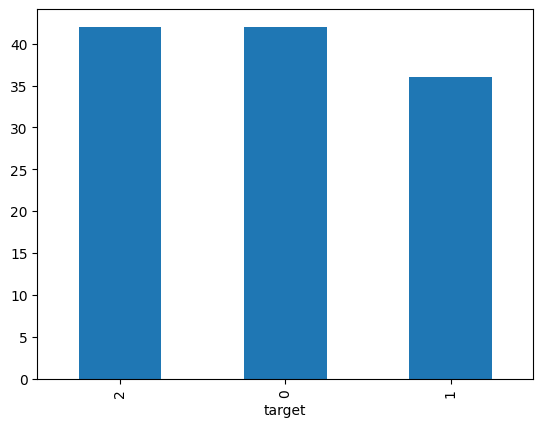

In [17]:
# Any class imbalance?
df_train['target'].value_counts().plot(kind='bar')

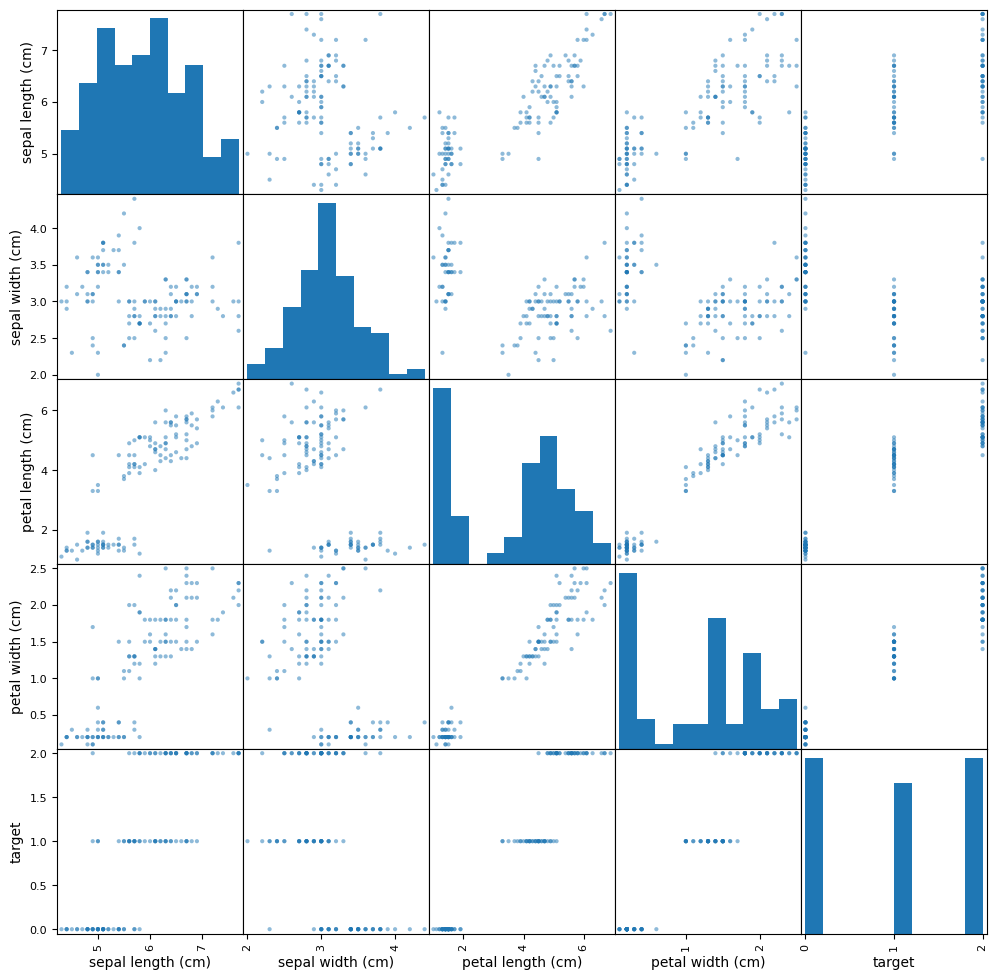

In [18]:
# Correlation between features?
pd.plotting.scatter_matrix(df_train, figsize=(12, 12))
# plt.tight_layout()
plt.show()

[Text(0.5, 0.9, 'petal length (cm) <= 2.6\ngini = 0.665\nsamples = 100.0%\nvalue = [0.35, 0.3, 0.35]\nclass = setosa'),
 Text(0.375, 0.7, 'gini = 0.0\nsamples = 35.0%\nvalue = [1.0, 0.0, 0.0]\nclass = setosa'),
 Text(0.4375, 0.8, 'True  '),
 Text(0.625, 0.7, 'petal width (cm) <= 1.75\ngini = 0.497\nsamples = 65.0%\nvalue = [0.0, 0.462, 0.538]\nclass = virginica'),
 Text(0.5625, 0.8, '  False'),
 Text(0.5, 0.5, 'petal length (cm) <= 4.95\ngini = 0.214\nsamples = 34.2%\nvalue = [0.0, 0.878, 0.122]\nclass = versicolor'),
 Text(0.25, 0.3, 'petal width (cm) <= 1.65\ngini = 0.056\nsamples = 29.2%\nvalue = [0.0, 0.971, 0.029]\nclass = versicolor'),
 Text(0.125, 0.1, 'gini = 0.0\nsamples = 28.3%\nvalue = [0.0, 1.0, 0.0]\nclass = versicolor'),
 Text(0.375, 0.1, 'gini = 0.0\nsamples = 0.8%\nvalue = [0.0, 0.0, 1.0]\nclass = virginica'),
 Text(0.75, 0.3, 'petal width (cm) <= 1.55\ngini = 0.444\nsamples = 5.0%\nvalue = [0.0, 0.333, 0.667]\nclass = virginica'),
 Text(0.625, 0.1, 'gini = 0.0\nsamples

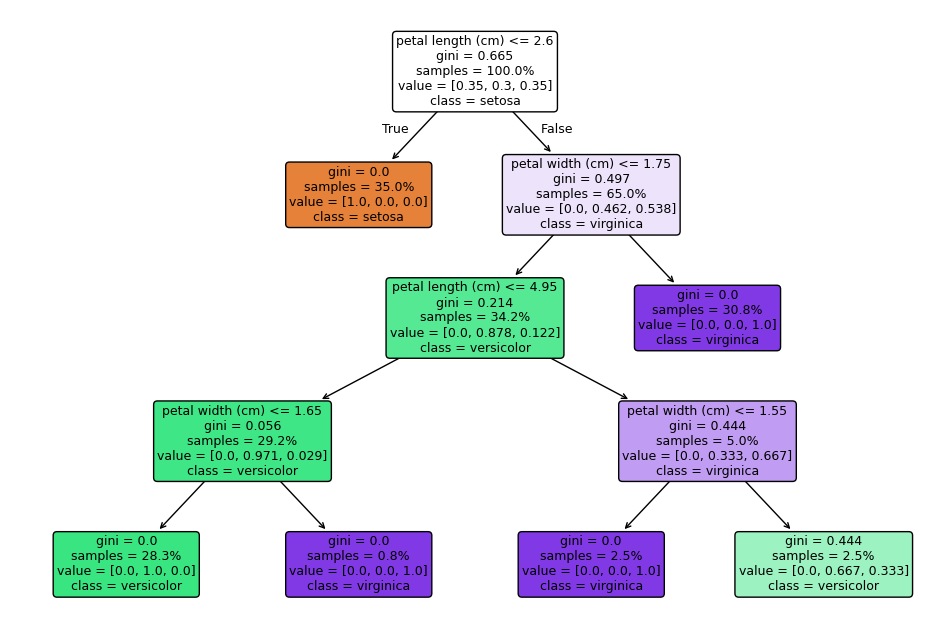

In [19]:
clf = tree.DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=1,
    # class_weight='balanced'
)
clf.fit(X_train, y_train)
plt.figure(figsize=(12, 8))
tree.plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True,
    filled=True,
    fontsize=9,
    proportion=True
)

### Check out how the model did


Feature importances: [0.         0.         0.57606287 0.42393713]
Test set accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      0.93      0.96        14
   virginica       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.98      0.97        30
weighted avg       0.97      0.97      0.97        30

F1 Macro: 0.9680464778503994
F1 Micro: 0.9666666666666667


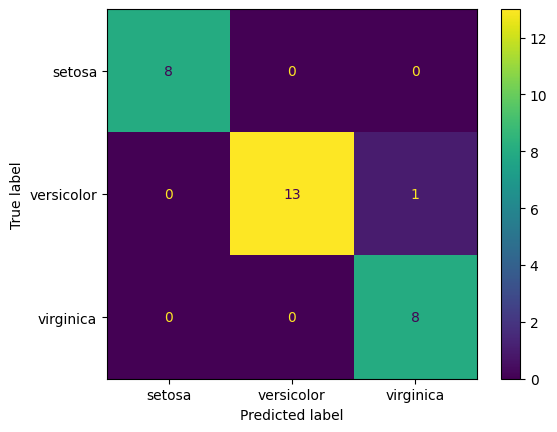

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score

print(f"Feature importances: {clf.feature_importances_}")
print(f"Test set accuracy: {clf.score(X_test, y_test)}")

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro')}")
print(f"F1 Micro: {f1_score(y_test, y_pred, average='micro')}")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=iris.target_names)

In [ ]:
c = classification_report(
    y_test, y_pred, target_names=iris.target_names, output_dict=True)
for key, value in c.items():
    if key in iris.target_names:
        print(
            f"Class: {key}, Precision: {value['precision']}, Recall: {value['recall']}, F1-score: {value['f1-score']}")
print(c.keys())

Class: setosa, Precision: 1.0, Recall: 1.0, F1-score: 1.0
Class: versicolor, Precision: 1.0, Recall: 0.9285714285714286, F1-score: 0.9629629629629629
Class: virginica, Precision: 0.8888888888888888, Recall: 1.0, F1-score: 0.9411764705882353
dict_keys([np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), 'accuracy', 'macro avg', 'weighted avg'])


## Regression Tree


In [22]:
import numpy as np

np.random.default_rng(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - np.random.rand(20))
print(X.shape, y.shape)

(100, 1) (100,)


In [23]:
reg_1 = tree.DecisionTreeRegressor(max_depth=3)
reg_1.fit(X, y)
reg_2 = tree.DecisionTreeRegressor(max_depth=5)
reg_2.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

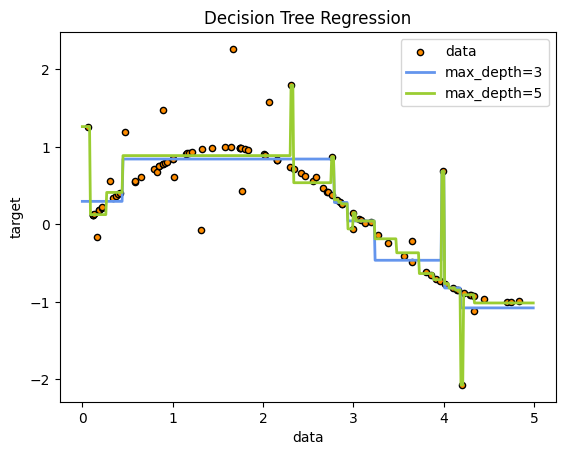

In [24]:
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = reg_1.predict(X_test)
y_2 = reg_2.predict(X_test)

plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=3", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

(100, 2)


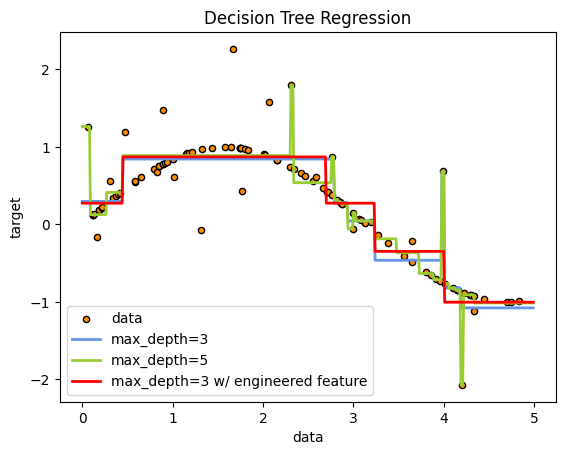

In [25]:
# What if we provide the model with an engineered sin(x) feature?
X_engineered = np.hstack((X, np.sin(X)))
print(X_engineered.shape)
reg_3 = tree.DecisionTreeRegressor(max_depth=2)
reg_3.fit(X_engineered, y)
y_3 = reg_3.predict(np.hstack((X_test, np.sin(X_test))))

plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=3", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.plot(X_test, y_3, color="red",
         label="max_depth=3 w/ engineered feature", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

[Text(0.5, 0.8333333333333334, 'x <= 3.232\nsquared_error = 0.544\nsamples = 100\nvalue = 0.313'),
 Text(0.25, 0.5, 'sin(x) <= 0.433\nsquared_error = 0.191\nsamples = 76\nvalue = 0.642'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.074\nsamples = 29\nvalue = 0.273'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.126\nsamples = 47\nvalue = 0.871'),
 Text(0.75, 0.5, 'sin(x) <= -0.759\nsquared_error = 0.226\nsamples = 24\nvalue = -0.731'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.095\nsamples = 14\nvalue = -1.005'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.159\nsamples = 10\nvalue = -0.349')]

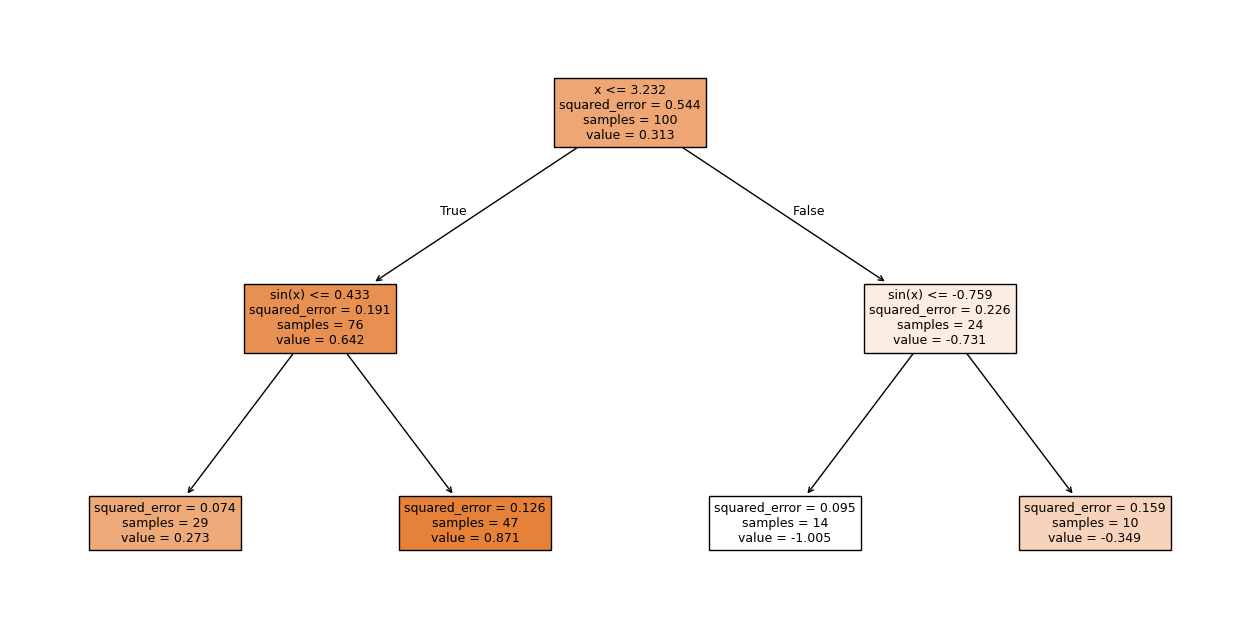

In [26]:
plt.figure(figsize=(16, 8))
tree.plot_tree(reg_3, filled=True, fontsize=9, feature_names=['x', 'sin(x)'])

### Regression Tree, Multiple Outputs


In [27]:
# Synthesize data
X = np.sort(200 * np.random.rand(100, 1) - 100, axis=0)
y = np.array([np.pi * np.sin(X).ravel(), np.pi * np.cos(X).ravel()]).T
# Add some noise
y[::5] += 0.5 - np.random.rand(20, 2)

In [28]:
reg_2 = tree.DecisionTreeRegressor(max_depth=2).fit(X, y)
reg_3 = tree.DecisionTreeRegressor(max_depth=3).fit(X, y)
reg_8 = tree.DecisionTreeRegressor(max_depth=8).fit(X, y)

In [29]:
X_test = np.arange(-100.0, 100.0, 1.)[:, np.newaxis]
y_1 = reg_2.predict(X_test)
y_2 = reg_3.predict(X_test)
y_3 = reg_8.predict(X_test)

/var/folders/br/rmys_1r571qbwgg30gx_x2l40000gn/T/ipykernel_3806/3599339898.py:4: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


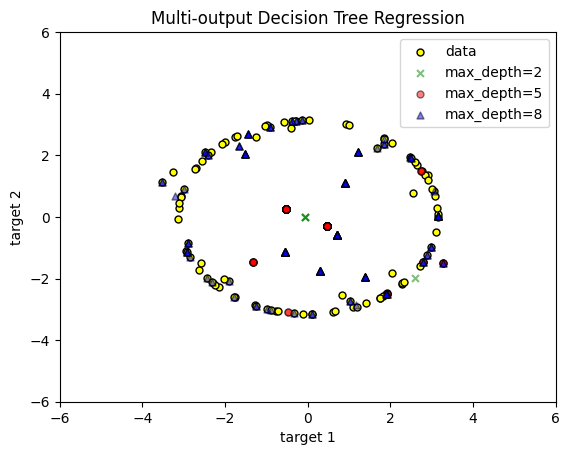

In [30]:
plt.figure()
s = 25
plt.scatter(y[:, 0], y[:, 1], c="yellow", s=s, edgecolor="black", label="data")
plt.scatter(
    y_1[::50, 0],
    y_1[::50, 1],
    c="green",
    s=s,
    marker='x',
    edgecolor="black",
    label="max_depth=2",
    alpha=0.5
)
plt.scatter(y_2[:, 0], y_2[:, 1], c="red", s=s, marker='o',
            edgecolor="black", label="max_depth=5", alpha=0.5)
plt.scatter(y_3[:, 0], y_3[:, 1], c="blue", s=s, marker='^',
            edgecolor="black", label="max_depth=8", alpha=0.5)
plt.xlim([-6, 6])
plt.ylim([-6, 6])
plt.xlabel("target 1")
plt.ylabel("target 2")
plt.title("Multi-output Decision Tree Regression")
plt.legend(loc="best")
plt.show()

We see that as we increase the tree depth, more points are pulled into the center due to fitting the noise. Let's try engineering the data to get better results.


In [ ]:
X_engineered = np.hstack((X, np.sin(X), np.cos(X)))
X_test = np.arange(-100.0, 100.0, 1.)[:, np.newaxis]
X_test_engineered = np.hstack((X_test, np.sin(X_test), np.cos(X_test)))
y_test = np.array([np.pi * np.sin(X_test).ravel(),
                  np.pi * np.cos(X_test).ravel()]).T
print(X_test.shape, y_test.shape)

(200, 1) (200, 2)


[Text(0.5, 0.8333333333333334, 'cos(x) <= -0.088\nsquared_error = 4.871\nsamples = 100\nvalue = [[0.049]\n[-0.162]]'),
 Text(0.25, 0.5, 'sin(x) <= -0.001\nsquared_error = 2.304\nsamples = 49\nvalue = [[0.11]\n[-2.253]]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.613\nsamples = 23\nvalue = [[-1.831]\n[-2.25]]'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.658\nsamples = 26\nvalue = [[1.828]\n[-2.256]]'),
 Text(0.75, 0.5, 'sin(x) <= 0.151\nsquared_error = 3.218\nsamples = 51\nvalue = [[-0.01]\n[1.846]]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 1.125\nsamples = 29\nvalue = [[-1.873]\n[2.062]]'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.605\nsamples = 22\nvalue = [[2.445]\n[1.561]]')]

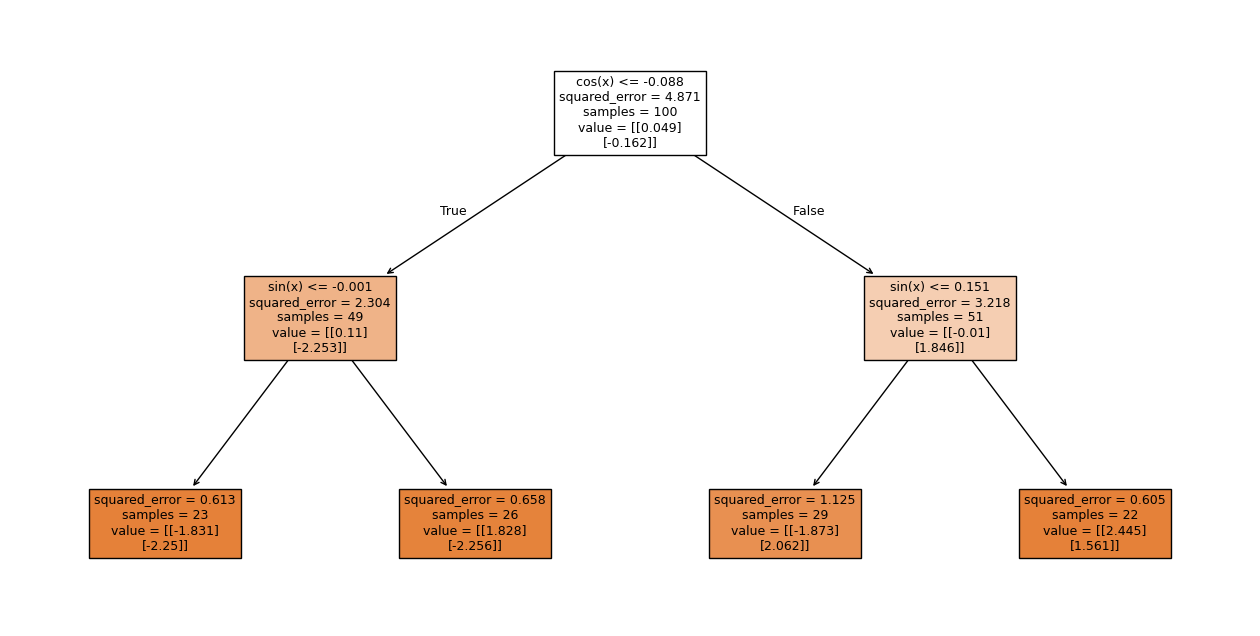

In [32]:
reg_eng_2 = tree.DecisionTreeRegressor(max_depth=2).fit(X_engineered, y)
y_eng_2 = reg_eng_2.predict(X_test_engineered)

plt.figure(figsize=(16, 8))
tree.plot_tree(reg_eng_2, filled=True, fontsize=9,
               feature_names=['x', 'sin(x)', 'cos(x)'])

## Imbalanced Data


In [111]:
from sklearn.datasets import make_classification
from collections import Counter

X, y = make_classification(
    n_classes=2,
    class_sep=2,
    weights=[0.7, 0.3],
    n_informative=5,
    n_redundant=0,
    flip_y=0,
    n_features=10,
    n_clusters_per_class=1,
    n_samples=2000,
    random_state=42
)

print(f"Class distribution: {Counter(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

Class distribution: Counter({np.int64(0): 1400, np.int64(1): 600})


In [113]:

param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc',
    'recall_macro': 'recall_macro'
}
clf = tree.DecisionTreeClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    clf,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    verbose=3
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5] END max_depth=3, min_samples_leaf=1, min_samples_split=2; accuracy: (test=1.000) f1_macro: (test=1.000) recall_macro: (test=1.000) roc_auc: (test=1.000) total time=   0.0s
[CV 2/5] END max_depth=3, min_samples_leaf=1, min_samples_split=2; accuracy: (test=1.000) f1_macro: (test=1.000) recall_macro: (test=1.000) roc_auc: (test=1.000) total time=   0.0s
[CV 3/5] END max_depth=3, min_samples_leaf=1, min_samples_split=2; accuracy: (test=1.000) f1_macro: (test=1.000) recall_macro: (test=1.000) roc_auc: (test=1.000) total time=   0.0s
[CV 4/5] END max_depth=3, min_samples_leaf=1, min_samples_split=2; accuracy: (test=1.000) f1_macro: (test=1.000) recall_macro: (test=1.000) roc_auc: (test=1.000) total time=   0.0s
[CV 5/5] END max_depth=3, min_samples_leaf=1, min_samples_split=2; accuracy: (test=1.000) f1_macro: (test=1.000) recall_macro: (test=1.000) roc_auc: (test=1.000) total time=   0.0s
[CV 1/5] END max_depth=3, min_sam

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'recall_macro': 'recall_macro', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intCon

In [114]:
grid_search.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [34]:
from sklearn.metrics import roc_auc_score
# Basic tree

for depth in [2, 3, 7]:
    tr = tree.DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        min_samples_leaf=5
    )
    tr.fit(X_train, y_train)
    y_pred = tr.predict(X_test)
    print(classification_report(y_test, y_pred, digits=4))

    roc_auc = roc_auc_score(
        y_test,
        tr.predict_proba(X_test),
        multi_class='ovr'
    )
    print(f"ROC AUC Score: {roc_auc}")
    print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro')}")
    print("==========")

              precision    recall  f1-score   support

           0     1.0000    0.9770    0.9883       217
           1     1.0000    0.9821    0.9910        56
           2     0.8182    1.0000    0.9000        27

    accuracy                         0.9800       300
   macro avg     0.9394    0.9864    0.9598       300
weighted avg     0.9836    0.9800    0.9809       300

ROC AUC Score: 0.99569826036985
F1 Macro: 0.9597786597786597
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       217
           1     1.0000    0.9821    0.9910        56
           2     0.9643    1.0000    0.9818        27

    accuracy                         0.9967       300
   macro avg     0.9881    0.9940    0.9909       300
weighted avg     0.9968    0.9967    0.9967       300

ROC AUC Score: 0.9999024199843872
F1 Macro: 0.990936390936391
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       217
      

### High Cardinality Categorical Feature with Class Imbalance


In [35]:
X, y = make_classification(
    n_classes=100,
    class_sep=1.0,
    weights=[0.5] + [0.5 / 99] * 99,
    n_informative=8,
    n_redundant=2,
    flip_y=0,
    n_features=10,
    n_clusters_per_class=1,
    n_samples=5000,
    random_state=42
)

print(f"Class distribution: {Counter(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

Class distribution: Counter({np.int64(0): 2501, np.int64(8): 26, np.int64(11): 26, np.int64(20): 26, np.int64(1): 26, np.int64(14): 26, np.int64(4): 26, np.int64(12): 26, np.int64(18): 26, np.int64(5): 26, np.int64(3): 26, np.int64(21): 26, np.int64(6): 26, np.int64(10): 26, np.int64(19): 26, np.int64(15): 26, np.int64(16): 26, np.int64(24): 26, np.int64(22): 26, np.int64(23): 26, np.int64(7): 26, np.int64(13): 26, np.int64(17): 26, np.int64(2): 26, np.int64(9): 26, np.int64(92): 25, np.int64(64): 25, np.int64(25): 25, np.int64(39): 25, np.int64(69): 25, np.int64(30): 25, np.int64(96): 25, np.int64(91): 25, np.int64(75): 25, np.int64(93): 25, np.int64(85): 25, np.int64(77): 25, np.int64(29): 25, np.int64(41): 25, np.int64(53): 25, np.int64(82): 25, np.int64(46): 25, np.int64(72): 25, np.int64(76): 25, np.int64(97): 25, np.int64(66): 25, np.int64(70): 25, np.int64(36): 25, np.int64(57): 25, np.int64(45): 25, np.int64(86): 25, np.int64(60): 25, np.int64(84): 25, np.int64(40): 25, np.int6

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder

X = pd.DataFrame({
    "income": [50000, 60000, 55000, 80000, 120000],
    "city": ["NYC", "LA", "NYC", "Chicago", "LA"],
    "color": ["red", "blue", "green", "red", "blue"],
    "size": ['S', 'M', 'L', 'XL', 'M'],
    "age":  [25, 30, 35, 40, 45]
})
y = [1, 0, 1, 0, 1]  # target
target_encoding_cols = ['city']
one_hot_encoding_cols = ['color', 'size']
# te = TargetEncoder(target_type='binary', cv=2, random_state=42)
# X['city_encoded'] = te.fit_transform(X[target_encoding_cols], y)

# one_hot = OneHotEncoder(sparse_output=False)
# X_one_hot_data = one_hot.fit_transform(X[one_hot_encoding_cols])

# df_one_hot = pd.DataFrame(
#     X_one_hot_data,
#     columns=one_hot.get_feature_names_out(one_hot_encoding_cols),
#     index=X.index
# )

# df_final = pd.concat(
#     [df_one_hot, X.drop(columns=one_hot_encoding_cols + target_encoding_cols)], axis=1
# )
# df_final.head()


preprocessor = ColumnTransformer(
    transformers=[
        ('target_encoder', TargetEncoder(target_type='binary',
         cv=2, random_state=42), target_encoding_cols),
        ('one_hot_encoder', OneHotEncoder(sparse_output=False), one_hot_encoding_cols)
    ],
    remainder='passthrough'
)
preprocessor.set_output(transform='pandas')
df_final = preprocessor.fit_transform(X, y)
df_final.head()

,target_encoder__city,one_hot_encoder__color_blue,one_hot_encoder__color_green,one_hot_encoder__color_red,one_hot_encoder__size_L,one_hot_encoder__size_M,one_hot_encoder__size_S,one_hot_encoder__size_XL,remainder__income,remainder__age
0,0.500000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,50000,25
1,0.666667,1.0,0.0,0.0,0.0,1.0,0.0,0.0,60000,30
2,0.500000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,55000,35
3,0.500000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,80000,40
4,0.666667,1.0,0.0,0.0,0.0,1.0,0.0,0.0,120000,45


### Custom Class Weights


In [38]:
custom_bal_tree = tree.DecisionTreeClassifier(
    max_depth=2,
    class_weight={0: 1.0, 1: 2.0, 2: 4.0},
    min_samples_leaf=5
)
custom_bal_tree.fit(X_train, y_train)
y_pred = custom_bal_tree.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro')}")

              precision    recall  f1-score   support

           0     0.5898    0.9799    0.7364       747
           1     0.0000    0.0000    0.0000         7
           2     0.0077    0.5000    0.0152         4
           3     0.0000    0.0000    0.0000        10
           4     0.0000    0.0000    0.0000        11
           5     0.0000    0.0000    0.0000        15
           6     0.0000    0.0000    0.0000         7
           7     0.0000    0.0000    0.0000         7
           8     0.0000    0.0000    0.0000         7
           9     0.0000    0.0000    0.0000         9
          10     0.0000    0.0000    0.0000        11
          11     0.0000    0.0000    0.0000         7
          12     0.0000    0.0000    0.0000         9
          13     0.0000    0.0000    0.0000        12
          14     0.0000    0.0000    0.0000         5
          15     0.0000    0.0000    0.0000         5
          16     0.0000    0.0000    0.0000         5
          17     0.0000    

/Users/benjaminbasseri/Dropbox/Studies/Programming/aiml/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/benjaminbasseri/Dropbox/Studies/Programming/aiml/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/benjaminbasseri/Dropbox/Studies/Programming/aiml/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

## Decision Tree On My Own


In [66]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
print(data.feature_names)
X = pd.DataFrame(data=data.data, columns=data.feature_names)
y = pd.Series(data=data.target)
y = 1 - y
print(data.target_names)
data.target_names = ['benign', 'malignant']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Data shape: {X_train.shape}, Target shape: {y_train.shape}")

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']
Data shape: (398, 30), Target shape: (398,)


In [67]:
# pd.plotting.scatter_matrix(X_train, figsize=(12, 12))

array([[<Axes: title={'center': 'mean radius'}>,
        <Axes: title={'center': 'mean texture'}>,
        <Axes: title={'center': 'mean perimeter'}>,
        <Axes: title={'center': 'mean area'}>,
        <Axes: title={'center': 'mean smoothness'}>],
       [<Axes: title={'center': 'mean compactness'}>,
        <Axes: title={'center': 'mean concavity'}>,
        <Axes: title={'center': 'mean concave points'}>,
        <Axes: title={'center': 'mean symmetry'}>,
        <Axes: title={'center': 'mean fractal dimension'}>],
       [<Axes: title={'center': 'radius error'}>,
        <Axes: title={'center': 'texture error'}>,
        <Axes: title={'center': 'perimeter error'}>,
        <Axes: title={'center': 'area error'}>,
        <Axes: title={'center': 'smoothness error'}>],
       [<Axes: title={'center': 'compactness error'}>,
        <Axes: title={'center': 'concavity error'}>,
        <Axes: title={'center': 'concave points error'}>,
        <Axes: title={'center': 'symmetry error'}>

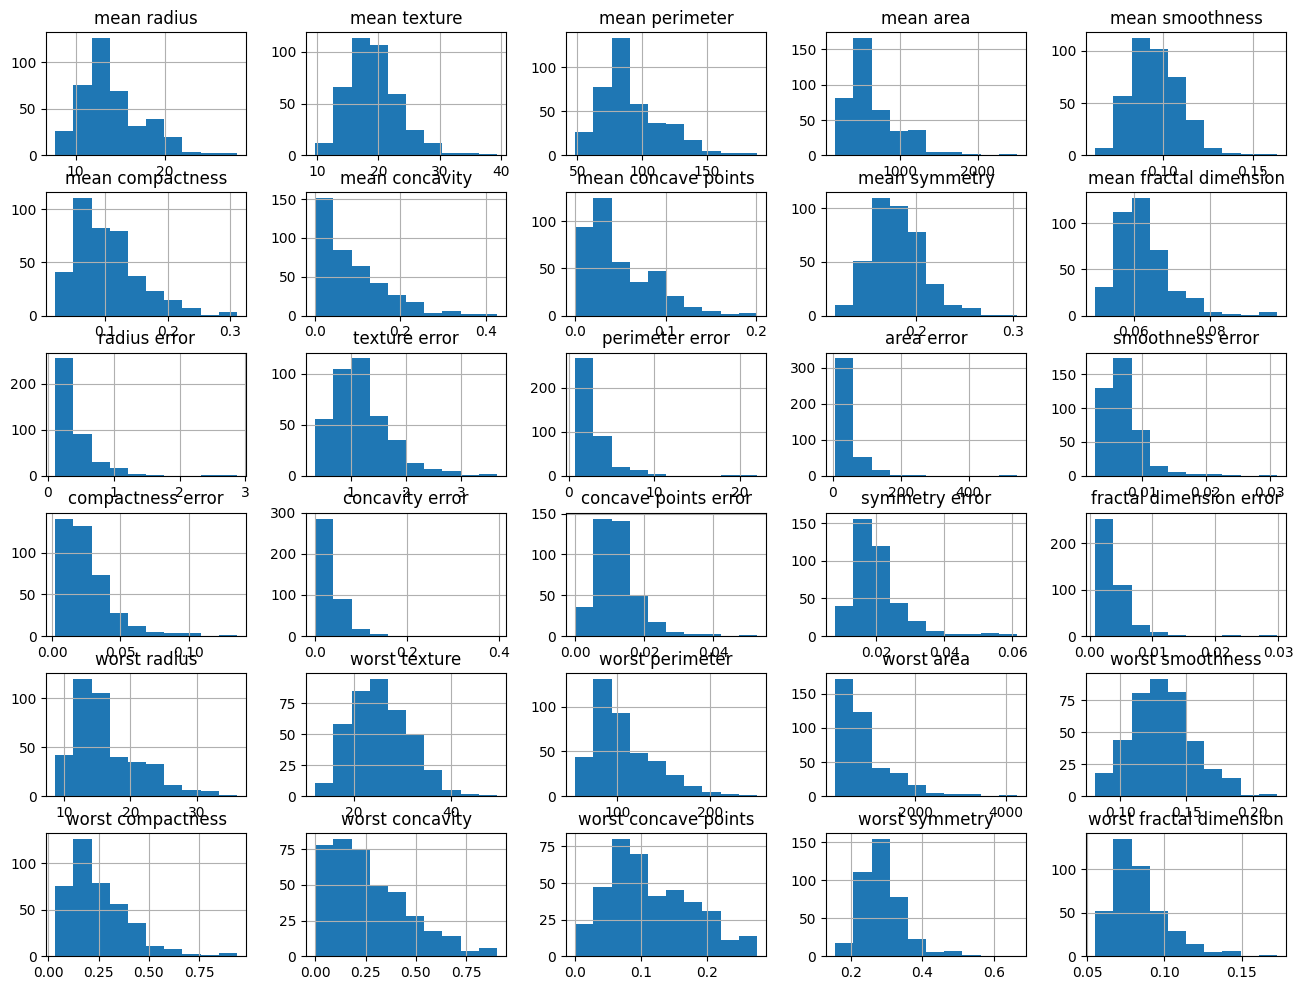

In [68]:
pd.plotting.hist_frame(X_train, figsize=(16, 12))

In [69]:
X_train['concavity error'].describe()

count    398.000000
mean       0.032259
std        0.030055
min        0.000000
25%        0.015180
50%        0.026140
75%        0.042500
max        0.396000
Name: concavity error, dtype: float64

<Axes: >

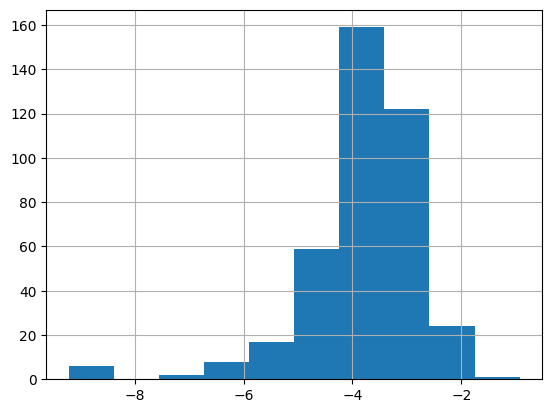

In [70]:
pd.plotting.hist_series(np.log(X_train['concavity error'] + 0.0001))

0    249
1    149
Name: count, dtype: int64


<Axes: >

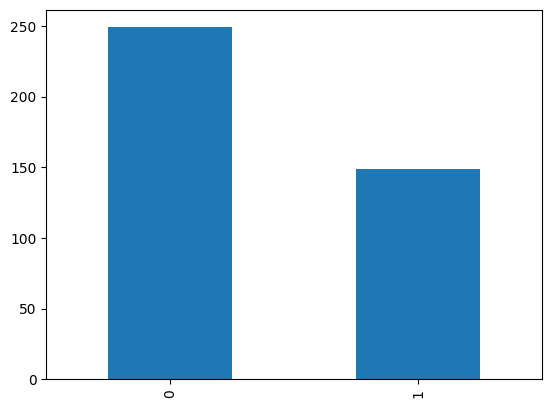

In [71]:
print(y_train.value_counts())
y_train.value_counts().plot(kind='bar')

### Adjusting the Prediction Threshold


In [72]:
data.target_names

['benign', 'malignant']

In [73]:
breast_cancer_detector = tree.DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight='balanced'
)
breast_cancer_detector.fit(X_train, y_train)
y_pred = breast_cancer_detector.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
roc = roc_auc_score(
    y_test,
    breast_cancer_detector.predict_proba(X_test)[:, 1]
)
print(f"ROC AUC Score: {roc}")

              precision    recall  f1-score   support

           0     0.9808    0.9444    0.9623       108
           1     0.9104    0.9683    0.9385        63

    accuracy                         0.9532       171
   macro avg     0.9456    0.9563    0.9504       171
weighted avg     0.9549    0.9532    0.9535       171

ROC AUC Score: 0.9736184597295708


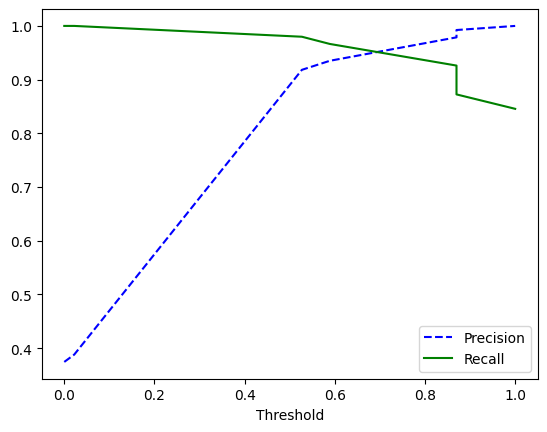

In [74]:
from sklearn.metrics import precision_recall_curve

y_train_preds = breast_cancer_detector.predict_proba(X_train)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, y_train_preds)
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [ ]:
# Choosing threshold of 0.6
def threshold_predictor(model, data, threshold=0.6):
    probs = model.predict_proba(data)[:, 1]
    return (probs >= threshold).astype(int)


y_pred_thresholded = threshold_predictor(
    breast_cancer_detector, X_test, threshold=0.6)
print(classification_report(y_test, y_pred_thresholded, digits=4))

              precision    recall  f1-score   support

           0     0.9725    0.9815    0.9770       108
           1     0.9677    0.9524    0.9600        63

    accuracy                         0.9708       171
   macro avg     0.9701    0.9669    0.9685       171
weighted avg     0.9707    0.9708    0.9707       171



In [45]:
# What if we use SMOTE to balance the classes?
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print(f"Resampled class distribution: {Counter(y_resampled)}")

# pipeline = ImbPipeline([
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(random_state=42)),
#     ('classifier', tree.DecisionTreeClassifier(
#         max_depth=4,
#         min_samples_leaf=5
#     ))
# ])

clf_smote = tree.DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=1
)
clf_smote.fit(X_resampled, y_resampled)
y_pred_smote = clf_smote.predict(X_test)
print("SMOTE Classifier Report")
print(classification_report(y_test, y_pred_smote, digits=4))
print(f"F1 Macro: {f1_score(y_test, y_pred_smote, average='macro')}")

Resampled class distribution: Counter({1: 249, 0: 249})
SMOTE Classifier Report
              precision    recall  f1-score   support

           0     0.8971    0.9683    0.9313        63
           1     0.9806    0.9352    0.9573       108

    accuracy                         0.9474       171
   macro avg     0.9388    0.9517    0.9443       171
weighted avg     0.9498    0.9474    0.9477       171

F1 Macro: 0.9443218407438225


In [ ]:
clf_unweighted = tree.DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=1,
)

clf_unweighted.fit(X, y)

clf_weighted = tree.DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=1,
    class_weight={0: 1.0, 1: 3.0}
)
clf_weighted.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [47]:
y_pred_unweighted = clf_unweighted.predict(X_test)
y_pred_weighted = clf_weighted.predict(X_test)
print("Unweighted Classifier Report")
print(classification_report(y_test, y_pred_unweighted, digits=4))
print(f"F1 Macro: {f1_score(y_test, y_pred_unweighted, average='macro')}")
print("Weighted Classifier Report")
print(classification_report(y_test, y_pred_weighted, digits=4))
print(f"F1 Macro: {f1_score(y_test, y_pred_weighted, average='macro')}")

Unweighted Classifier Report
              precision    recall  f1-score   support

           0     0.9836    0.9524    0.9677        63
           1     0.9727    0.9907    0.9817       108

    accuracy                         0.9766       171
   macro avg     0.9782    0.9716    0.9747       171
weighted avg     0.9767    0.9766    0.9765       171

F1 Macro: 0.97469665581533
Weighted Classifier Report
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        63
           1     1.0000    1.0000    1.0000       108

    accuracy                         1.0000       171
   macro avg     1.0000    1.0000    1.0000       171
weighted avg     1.0000    1.0000    1.0000       171

F1 Macro: 1.0


[Text(0.7645089285714286, 0.9444444444444444, 'worst perimeter <= 117.45\ngini = 0.276\nsamples = 569\nvalue = [212.0, 1071.0]\nclass = benign'),
 Text(0.6004464285714286, 0.8333333333333334, 'worst concave points <= 0.16\ngini = 0.081\nsamples = 402\nvalue = [47, 1065]\nclass = benign'),
 Text(0.6824776785714286, 0.8888888888888888, 'True  '),
 Text(0.45089285714285715, 0.7222222222222222, 'worst area <= 957.45\ngini = 0.047\nsamples = 379\nvalue = [26.0, 1059.0]\nclass = benign'),
 Text(0.33035714285714285, 0.6111111111111112, 'worst concave points <= 0.136\ngini = 0.038\nsamples = 373\nvalue = [21, 1056]\nclass = benign'),
 Text(0.19642857142857142, 0.5, 'worst fractal dimension <= 0.055\ngini = 0.018\nsamples = 343\nvalue = [9, 1002]\nclass = benign'),
 Text(0.16071428571428573, 0.3888888888888889, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = malignant'),
 Text(0.23214285714285715, 0.3888888888888889, 'worst radius <= 16.805\ngini = 0.016\nsamples = 342\nvalue = [8, 1002]\ncla

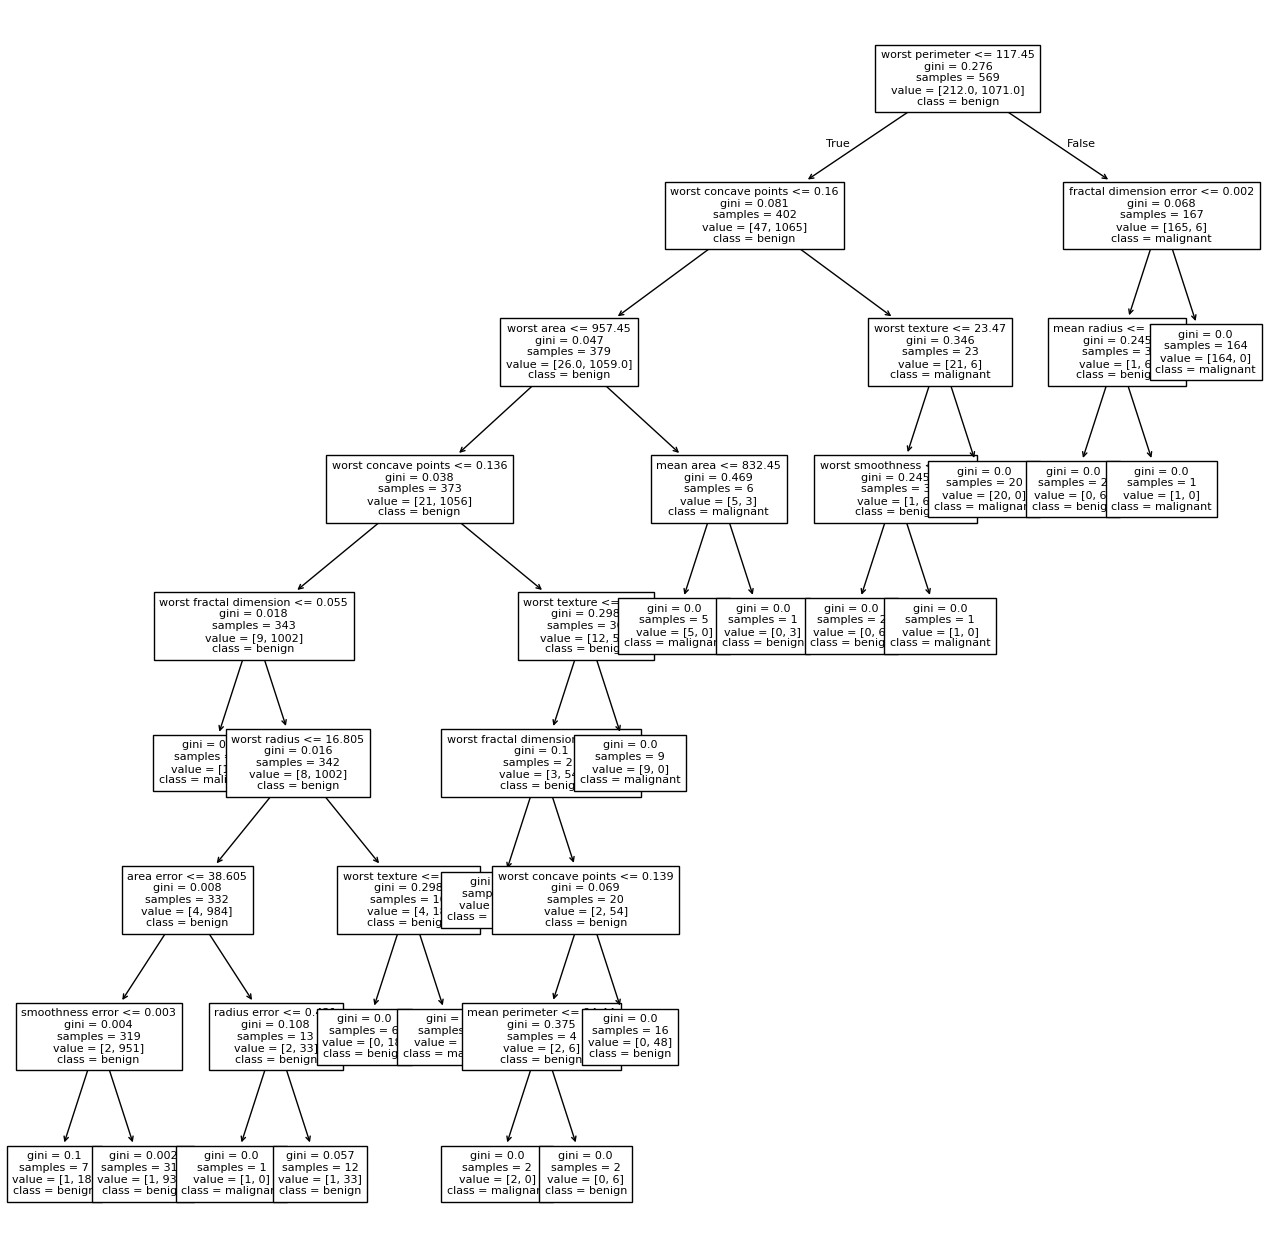

In [ ]:
plt.figure(figsize=(16, 16))
tree.plot_tree(clf_weighted,
               fontsize=8,
               feature_names=data.feature_names,
               class_names=data.target_names
               )

array([[<Axes: xlabel='feature_1', ylabel='feature_1'>,
        <Axes: xlabel='feature_2', ylabel='feature_1'>,
        <Axes: xlabel='target', ylabel='feature_1'>],
       [<Axes: xlabel='feature_1', ylabel='feature_2'>,
        <Axes: xlabel='feature_2', ylabel='feature_2'>,
        <Axes: xlabel='target', ylabel='feature_2'>],
       [<Axes: xlabel='feature_1', ylabel='target'>,
        <Axes: xlabel='feature_2', ylabel='target'>,
        <Axes: xlabel='target', ylabel='target'>]], dtype=object)

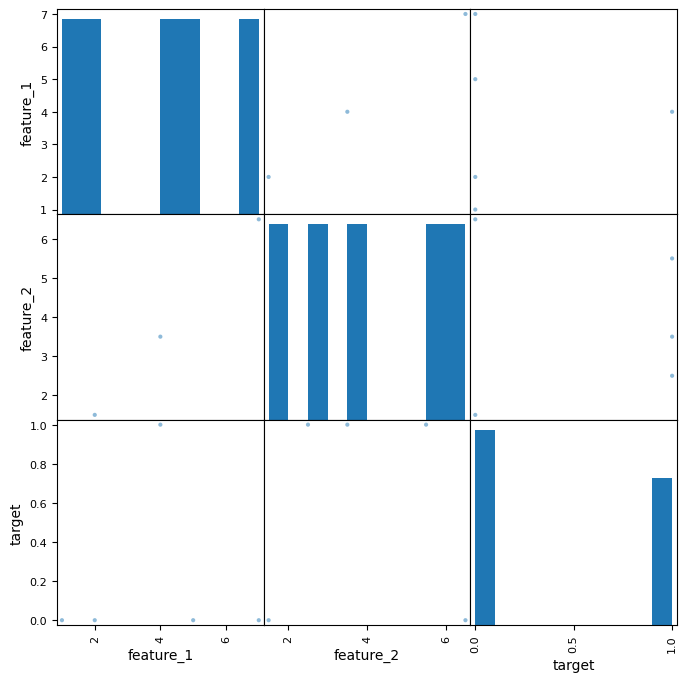

In [103]:
# Test classification decision tree on data frame with missing data
# Import simple imputer
from sklearn.impute import SimpleImputer
df = pd.DataFrame({
    'feature_1': [1.0, 2.0, np.nan, 4.0, 5.0, np.nan, 7.0],
    'feature_2': [np.nan, 1.5, 2.5, 3.5, np.nan, 5.5, 6.5],
    'target': [0, 0, 1, 1, 0, 1, 0]
})

pd.plotting.scatter_matrix(df, figsize=(8, 8))
# simple_imputer = SimpleImputer(strategy='constant', fill_value=-1)
# df[['feature_1', 'feature_2']] = simple_imputer.fit_transform(
#     df[['feature_1', 'feature_2']])
# df['squares'] = df.feature_1.apply(lambda x: x**2 if x != -1 else x)
# df['is_large'] = df.feature_2.apply(lambda x: x > 3.0)
# df
# X = df[['feature_1', 'feature_2']]
# y = df['target']
# clf_missing = tree.DecisionTreeClassifier(max_depth=2)
# clf_missing.fit(X, y)
# tree.plot_tree(clf_missing, filled=True, fontsize=9)

In [89]:
df = pd.DataFrame({"color": ["red", "blue", "red"]})

dummies = pd.get_dummies(df, columns=['color'])
df = pd.concat([df.drop('color', axis=1), dummies], axis=1)
print(df)

   color_blue  color_red
0       False       True
1        True      False
2       False       True


## Gradient Boosted Trees


In [92]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import make_hastie_10_2

X, y = make_hastie_10_2(random_state=0)
X_train, X_test = X[:2000], X[2000:]
y_train, y_test = y[:2000], y[2000:]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (2000, 10), y_train shape: (2000,)
X_test shape: (10000, 10), y_test shape: (10000,)


In [93]:
clf_hbg = HistGradientBoostingClassifier(max_iter=100).fit(X_train, y_train)
print(clf_hbg.score(X_test, y_test))

0.8965
